In [1]:
import sys
sys.path.insert(1, '../src/')
from preprocessing import *

In [2]:
import matplotlib.pyplot as plt
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

RAW_DATA_PATH = config["raw_data_path"]
ELEMENTS_DICT = config["elements_dict"]
N_STD = config["n_std"]
N_DES = config["n_des"]
BUNCH_NO = config["bunch_no"]
KEEP_FE = config["keep_fe"]
TO_FE = config["to_fe"]

### Loading the data

In [5]:
# load raw
raw_df = read_raw_file(RAW_DATA_PATH)

selected = select_expected_columns(raw_df, ELEMENTS_DICT.keys())

# initial rounding and despike
cleaned = round_and_despike_df(selected)

# normalize by elements_dict mapping
normalized = normalize_by_elements_dict(cleaned, ELEMENTS_DICT)

# subtract blank and clip
arr = normalized.values
normalized_blank = subtract_blank_and_clip(arr, n_std=N_STD)

# optional additional despike passes
normalized_blank = apply_multiple_despike(normalized_blank, n_des=N_DES)

# final dataframe after despike
despike_df = pd.DataFrame(normalized_blank, columns=normalized.columns).dropna()

# sort and create bunches
bunched = sort_and_bunch(despike_df, bunch_no=BUNCH_NO)

# optional normalize to Fe
if TO_FE:
    bunched = normalize_to_fe(bunched, keep_fe=True)


In [6]:
dfs = [selected, cleaned, normalized, normalized_blank, despike_df, bunched]

### Visualisation

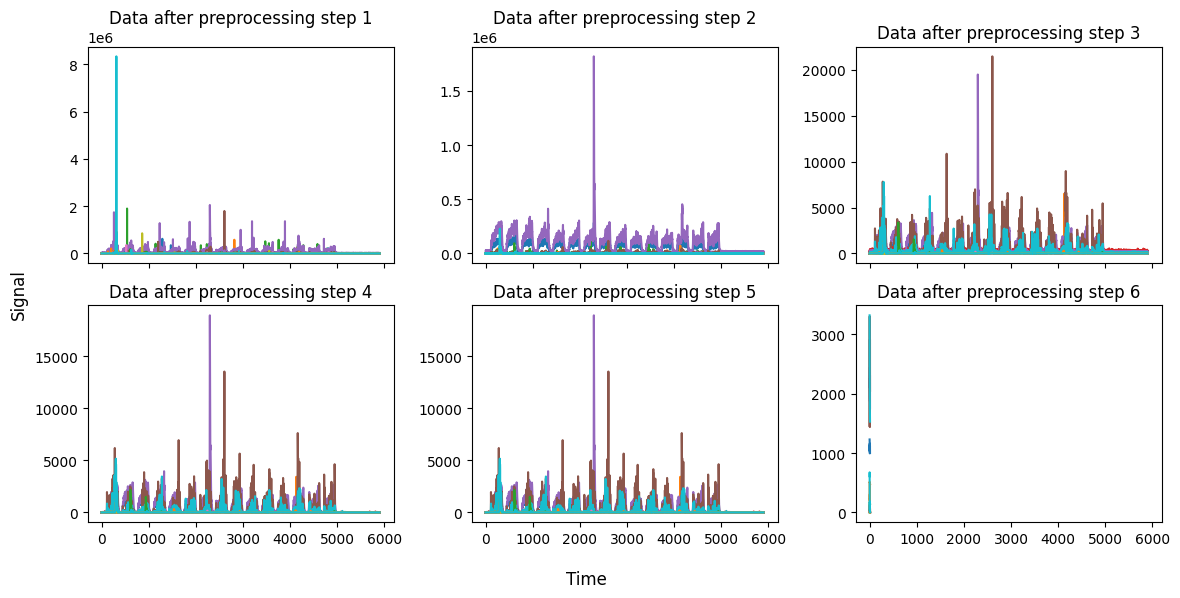

In [8]:
# Create figure and subplots: 2 rows, 3 columns
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    sharex=True,
    figsize=(12, 6)
)

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot each data vector
for i, ax in enumerate(axes):
    ax.plot(dfs[i])
    ax.set_title(f'Data after preprocessing step {i+1}')

# Label shared axes
fig.supxlabel('Time')
fig.supylabel('Signal')

# Improve layout
plt.tight_layout()
plt.show()